In [27]:
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import common_mod_1 as cmm

In [2]:
adult_census = cmm.dfFromArffFile('/data/phpMawTba.arff')
adult_census.drop(columns=['education-num', 'fnlwgt'], inplace=True)
adult_census.columns

Metadata =============================================
 Dataset: adult
	age's type is numeric
	workclass's type is nominal, range is ('Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Federal-gov', 'Local-gov', 'State-gov', 'Without-pay', 'Never-worked')
	fnlwgt's type is numeric
	education's type is nominal, range is ('Bachelors', 'Some-college', '11th', 'HS-grad', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', '9th', '7th-8th', '12th', 'Masters', '1st-4th', '10th', 'Doctorate', '5th-6th', 'Preschool')
	education-num's type is numeric
	marital-status's type is nominal, range is ('Married-civ-spouse', 'Divorced', 'Never-married', 'Separated', 'Widowed', 'Married-spouse-absent', 'Married-AF-spouse')
	occupation's type is nominal, range is ('Tech-support', 'Craft-repair', 'Other-service', 'Sales', 'Exec-managerial', 'Prof-specialty', 'Handlers-cleaners', 'Machine-op-inspct', 'Adm-clerical', 'Farming-fishing', 'Transport-moving', 'Priv-house-serv', 'Protective-serv', 'Armed-Forces')
	relationshi

Index(['age', 'workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [3]:
str_cols = adult_census.select_dtypes(include='object').columns
for col in str_cols:
    adult_census[col] = adult_census[col].str.decode('utf-8')
adult_census


,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25.0,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0.0,0.0,40.0,United-States,<=50K
1,38.0,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.0,0.0,50.0,United-States,<=50K
2,28.0,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
3,44.0,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0,United-States,>50K
4,18.0,?,Some-college,Never-married,?,Own-child,White,Female,0.0,0.0,30.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,38.0,United-States,<=50K
48838,40.0,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
48839,58.0,Private,HS-grad,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,40.0,United-States,<=50K
48840,22.0,Private,HS-grad,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,20.0,United-States,<=50K


In [4]:
features, target = adult_census[adult_census.columns.difference(['class'])], adult_census["class"]

In [5]:
features

,age,capital-gain,capital-loss,education,hours-per-week,marital-status,native-country,occupation,race,relationship,sex,workclass
0,25.0,0.0,0.0,11th,40.0,Never-married,United-States,Machine-op-inspct,Black,Own-child,Male,Private
1,38.0,0.0,0.0,HS-grad,50.0,Married-civ-spouse,United-States,Farming-fishing,White,Husband,Male,Private
2,28.0,0.0,0.0,Assoc-acdm,40.0,Married-civ-spouse,United-States,Protective-serv,White,Husband,Male,Local-gov
3,44.0,7688.0,0.0,Some-college,40.0,Married-civ-spouse,United-States,Machine-op-inspct,Black,Husband,Male,Private
4,18.0,0.0,0.0,Some-college,30.0,Never-married,United-States,?,White,Own-child,Female,?
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,0.0,0.0,Assoc-acdm,38.0,Married-civ-spouse,United-States,Tech-support,White,Wife,Female,Private
48838,40.0,0.0,0.0,HS-grad,40.0,Married-civ-spouse,United-States,Machine-op-inspct,White,Husband,Male,Private
48839,58.0,0.0,0.0,HS-grad,40.0,Widowed,United-States,Adm-clerical,White,Unmarried,Female,Private
48840,22.0,0.0,0.0,HS-grad,20.0,Never-married,United-States,Adm-clerical,White,Own-child,Male,Private


In [6]:
target

0        <=50K
1        <=50K
2         >50K
3         >50K
4        <=50K
         ...  
48837    <=50K
48838     >50K
48839    <=50K
48840    <=50K
48841     >50K
Name: class, Length: 48842, dtype: object

In [7]:
features.describe()

,age,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1079.067626,87.502314,40.422382
std,13.710510,7452.019058,403.004552,12.391444
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


T**RAIN-TEST SPLIT THE DATASET**

In [8]:
features_num = features.select_dtypes(exclude='object')
features_train, features_test, target_train, target_test = train_test_split(features_num, target, random_state=31,
                                                                            test_size=.25)
features_train.dtypes

age               float64
capital-gain      float64
capital-loss      float64
hours-per-week    float64
dtype: object

In [9]:
print(
    f'Shapes. features_train = {features_train.shape}, features_test = {features_test.shape}, target_train = {target_train.shape}, target_test = {target_test.shape}')

Shapes. features_train = (36631, 4), features_test = (12211, 4), target_train = (36631,), target_test = (12211,)


In [10]:

modelLog = LogisticRegression()
modelLog.fit(features_train, target_train)
accuaracy = modelLog.score(features_test, target_test)
accuaracy

0.8027188600442224

**USING A DUMMY CLASSIFIER**

In [11]:
model_dumm = DummyClassifier(strategy='constant', constant='<=50K', random_state=0)
model_dumm.fit(features_train, target_train)
model_dumm.score(features_test, target_test)

0.7630824666284498

**MODEL FITTING WITH PREPROCESSING**

In [12]:
scaler = StandardScaler()
scaler.fit(features_train)

,copy,True
,with_mean,True
,with_std,True


In [13]:
scaler.mean_

array([  38.6918457 , 1073.16103846,   87.11842429,   40.41552237])

In [14]:
scaler.scale_

array([  13.70244592, 7431.29023905,  401.65028534,   12.3595374 ])

In [15]:
features_train_scaled = scaler.transform(features_train)
print(type(features_train_scaled))
features_train_scaled

<class 'numpy.ndarray'>


array([[ 1.70102144, -0.14441113, -0.21690119,  2.39365574],
       [ 0.38738736, -0.14441113,  4.48121573,  1.18001808],
       [ 0.24142801, -0.14441113, -0.21690119, -0.03361957],
       ...,
       [-0.26942969, -0.14441113, -0.21690119,  0.37092631],
       [-0.63432804, -0.14441113, -0.21690119,  0.69456302],
       [-0.4883687 ,  0.23627646, -0.21690119, -0.03361957]],
      shape=(36631, 4))

In [16]:
scaler.fit_transform(features_train)

array([[ 1.70102144, -0.14441113, -0.21690119,  2.39365574],
       [ 0.38738736, -0.14441113,  4.48121573,  1.18001808],
       [ 0.24142801, -0.14441113, -0.21690119, -0.03361957],
       ...,
       [-0.26942969, -0.14441113, -0.21690119,  0.37092631],
       [-0.63432804, -0.14441113, -0.21690119,  0.69456302],
       [-0.4883687 ,  0.23627646, -0.21690119, -0.03361957]],
      shape=(36631, 4))

In [17]:
scaler_df = StandardScaler().set_output(transform='pandas')
features_train_scaled_df = scaler_df.fit_transform(features_train)
features_train_scaled_df.describe()

,age,capital-gain,capital-loss,hours-per-week
count,3.663100e+04,3.663100e+04,3.663100e+04,3.663100e+04
mean,-1.871840e-16,6.983030e-18,2.909596e-17,-1.903846e-16
std,1.000014e+00,1.000014e+00,1.000014e+00,1.000014e+00
min,-1.583064e+00,-1.444111e-01,-2.169012e-01,-3.189077e+00
25%,-7.802874e-01,-1.444111e-01,-2.169012e-01,-3.361957e-02
50%,-1.234703e-01,-1.444111e-01,-2.169012e-01,-3.361957e-02
75%,6.793060e-01,-1.444111e-01,-2.169012e-01,3.709263e-01
max,3.744452e+00,1.331207e+01,1.062835e+01,4.740022e+00


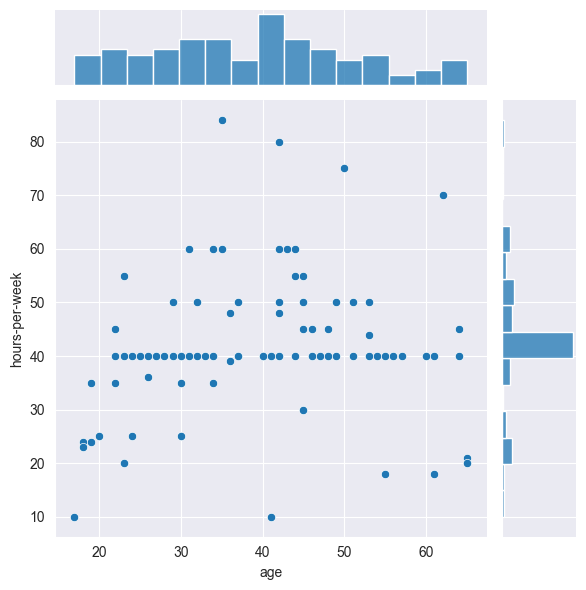

In [22]:
sample_plot = 100
sns.jointplot(data=features_train[:sample_plot], x="age", y="hours-per-week", marginal_kws=dict(bins=15))

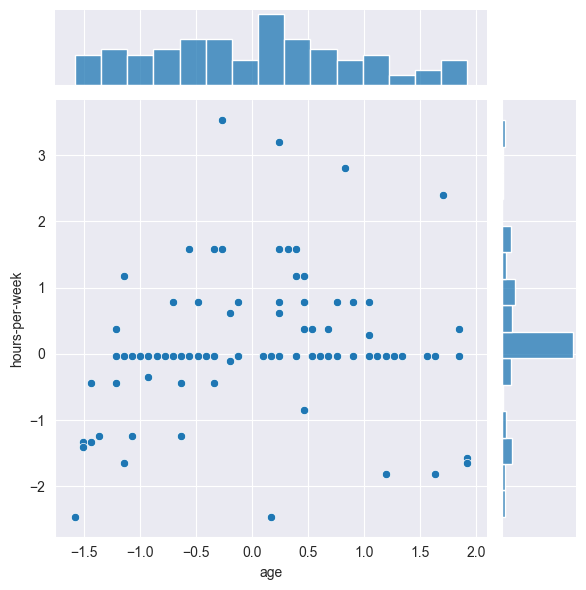

In [25]:
sns.jointplot(data=features_train_scaled_df[:sample_plot], x='age', y='hours-per-week', marginal_kws=dict(bins=15))

**PIPELINES**

In [28]:
model_pipe1 = make_pipeline(StandardScaler(), LogisticRegression())
model_pipe1

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [40]:
print(f'name of the class: {model_pipe1.__class__.__name__}')
model_pipe1.__dict__

name of the class: Pipeline


{'steps': [('standardscaler', StandardScaler()),
  ('logisticregression', LogisticRegression())],
 'transform_input': None,
 'memory': None,
 'verbose': False}

In [29]:
model_pipe1.steps

[('standardscaler', StandardScaler()),
 ('logisticregression', LogisticRegression())]

When calling model.fit, the method fit_transform from each underlying transformer (here a single transformer) in the pipeline is called.

In [30]:
model_pipe1.fit(features_train, target_train)

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [33]:
predicted_pipe1 = model_pipe1.predict(features_test)
predicted_pipe1

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      shape=(12211,), dtype=object)

In [35]:
predicted_pipe1[predicted_pipe1 != '<=50K']

array(['>50K', '>50K', '>50K', ..., '>50K', '>50K', '>50K'],
      shape=(1191,), dtype=object)

In [36]:
predicted_pipe1[predicted_pipe1 != '>50K']

array(['<=50K', '<=50K', '<=50K', ..., '<=50K', '<=50K', '<=50K'],
      shape=(11020,), dtype=object)

In [37]:
# noinspection PyUnresolvedReferences
(predicted_pipe1 != '>50K').mean()

np.float64(0.9024649905822619)

In [51]:
score_pipe = model_pipe1.score(features_test, target_test)
print(f'score_pipe = {score_pipe}')
model_pipe1[-1].n_iter_

score_pipe = 0.8028007534190484


array([10], dtype=int32)